# 05 Volatility Risk Premium

**Book:** *Expected Returns - An Investor's Guide to Harvesting Market Rewards*  
**Focus:** Build a local volatility risk premium scaffold using internal `SPY`, `VIX`, and `VIX3M` parquet series only.


## Proxy Scope And Local-Data Limits

This notebook intentionally uses only internal parquet data available in the repo:

- `data/market_data/prices/spy_ohlc.parquet`
- `data/market_data/prices/vix_daily.parquet`
- `data/market_data/prices/vix3m_daily.parquet`

Practical constraints versus a full production VRP build:

1. `VIX` and `VIX3M` are used as implied-volatility proxies; no option chain-level variance swap replication is attempted.
2. Realized volatility is estimated from `SPY` close-to-close returns only.
3. This is a research scaffold for Chapter 15-style diagnostics, not a tradable implementation.


In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path("/Users/zelin/Desktop/PA Investment/Invest_strategy")
STUDY_DIR = REPO_ROOT / "workstation" / "playground" / "studies" / "2026-03-29_expected_returns_ilmanen"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
if str(STUDY_DIR) not in sys.path:
    sys.path.insert(0, str(STUDY_DIR))

from local_parquet import (
    load_named_price_series,
    simple_returns,
    annualized_realized_vol,
    forward_return,
    rolling_zscore,
)

warnings.filterwarnings("ignore")

START = "2006-07-17"
END = "2026-02-27"
OUT_CSV = STUDY_DIR / "05_volatility_risk_premium_panel.csv"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

print("Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.")
print("Repo root:", REPO_ROOT)
print("Study dir:", STUDY_DIR)


Expected environment: conda activate ibkr-analytics && export PYTHONPATH=.
Repo root: /Users/zelin/Desktop/PA Investment/Invest_strategy
Study dir: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen


In [2]:
spy_close = load_named_price_series("spy_ohlc", value_col="close", start=START, end=END).rename("spy")
vix_close = load_named_price_series("vix_daily", value_col="close", start=START, end=END).rename("vix")
vix3m_close = load_named_price_series("vix3m_daily", value_col="close", start=START, end=END).rename("vix3m")

panel = pd.concat([spy_close, vix_close, vix3m_close], axis=1).dropna().copy()
panel.index = pd.to_datetime(panel.index)
panel.index.name = "date"

print("Panel shape:", panel.shape)
print("Date range:", panel.index.min().date(), "to", panel.index.max().date())
panel.tail()


Panel shape: (4936, 3)
Date range: 2006-07-17 to 2026-02-27


                   spy        vix      vix3m
date                                        
2026-02-23  682.390015  21.010000  22.139999
2026-02-24  687.349976  19.549999  21.340000
2026-02-25  693.150024  17.930000  20.360001
2026-02-26  689.299988  18.629999  20.809999
2026-02-27  685.989990  19.860001  21.559999

In [3]:
spy_ret = simple_returns(panel["spy"])
panel["rv_21d_ann"] = annualized_realized_vol(spy_ret, window=21)
panel["rv_63d_ann"] = annualized_realized_vol(spy_ret, window=63)

panel["iv_vix_ann"] = panel["vix"] / 100.0
panel["iv_vix3m_ann"] = panel["vix3m"] / 100.0

panel["vrp_vix_minus_rv21"] = panel["iv_vix_ann"] - panel["rv_21d_ann"]
panel["vrp_vix3m_minus_rv21"] = panel["iv_vix3m_ann"] - panel["rv_21d_ann"]
panel["term_structure_vix3m_minus_vix"] = panel["iv_vix3m_ann"] - panel["iv_vix_ann"]

panel["vrp_vix_minus_rv21_z252"] = rolling_zscore(panel["vrp_vix_minus_rv21"], window=252)
panel["term_structure_z252"] = rolling_zscore(panel["term_structure_vix3m_minus_vix"], window=252)

vrp_cols = [
    "iv_vix_ann",
    "iv_vix3m_ann",
    "rv_21d_ann",
    "vrp_vix_minus_rv21",
    "vrp_vix3m_minus_rv21",
    "term_structure_vix3m_minus_vix",
]
panel[vrp_cols].dropna().tail()


            iv_vix_ann  iv_vix3m_ann  rv_21d_ann  vrp_vix_minus_rv21  vrp_vix3m_minus_rv21  term_structure_vix3m_minus_vix
date                                                                                                                      
2026-02-23      0.2101        0.2214    0.120656            0.089444              0.100744                          0.0113
2026-02-24      0.1955        0.2134    0.123564            0.071936              0.089836                          0.0179
2026-02-25      0.1793        0.2036    0.125866            0.053434              0.077734                          0.0243
2026-02-26      0.1863        0.2081    0.126453            0.059847              0.081647                          0.0218
2026-02-27      0.1986        0.2156    0.127361            0.071239              0.088239                          0.0170

In [4]:
panel["fwd_21d_spy"] = forward_return(panel["spy"], horizon=21)
panel["fwd_63d_spy"] = forward_return(panel["spy"], horizon=63)

analysis = panel[[
    "vrp_vix_minus_rv21",
    "term_structure_vix3m_minus_vix",
    "fwd_21d_spy",
    "fwd_63d_spy",
]].dropna().copy()

corr = analysis.corr().round(3)
quintile_stats = (
    analysis.assign(vrp_quintile=pd.qcut(analysis["vrp_vix_minus_rv21"], q=5, labels=False, duplicates="drop"))
    .groupby("vrp_quintile")[["fwd_21d_spy", "fwd_63d_spy"]]
    .mean()
    .mul(100.0)
    .rename(columns={"fwd_21d_spy": "fwd_21d_spy_pct", "fwd_63d_spy": "fwd_63d_spy_pct"})
)

print("Correlation matrix:")
print(corr.to_string())
print("\nMean forward SPY returns by VRP quintile (%):")
quintile_stats


Correlation matrix:
                                vrp_vix_minus_rv21  term_structure_vix3m_minus_vix  fwd_21d_spy  fwd_63d_spy
vrp_vix_minus_rv21                           1.000                           0.198        0.036        0.041
term_structure_vix3m_minus_vix               0.198                           1.000        0.002        0.002
fwd_21d_spy                                  0.036                           0.002        1.000        0.559
fwd_63d_spy                                  0.041                           0.002        0.559        1.000

Mean forward SPY returns by VRP quintile (%):


              fwd_21d_spy_pct  fwd_63d_spy_pct
vrp_quintile                                  
0                    0.844308         2.038479
1                    0.466798         2.064830
2                    0.555004         2.055495
3                    0.517508         2.029852
4                    1.794990         4.106378

In [5]:
VRP_QUINTILE_EXTENDED_CSV = STUDY_DIR / "05_vrp_quintile_extended.csv"
VRP_REGRESSION_COEFFS_CSV = STUDY_DIR / "05_vrp_regression_coeffs.csv"

panel["fwd_rv_21d_ann"] = (
    simple_returns(panel["spy"]).shift(-1).rolling(21, min_periods=21).std().shift(-20) * np.sqrt(252)
)
panel["fwd_rv_63d_ann"] = (
    simple_returns(panel["spy"]).shift(-1).rolling(63, min_periods=63).std().shift(-62) * np.sqrt(252)
)

vrp_extended = panel[[
    "vrp_vix_minus_rv21",
    "term_structure_vix3m_minus_vix",
    "fwd_21d_spy",
    "fwd_63d_spy",
    "fwd_rv_21d_ann",
    "fwd_rv_63d_ann",
]].dropna().copy()
vrp_extended["vrp_quintile"] = pd.qcut(vrp_extended["vrp_vix_minus_rv21"], q=5, labels=False, duplicates="drop")

quintile_extended = (
    vrp_extended.groupby("vrp_quintile", observed=True)[["fwd_21d_spy", "fwd_63d_spy", "fwd_rv_21d_ann", "fwd_rv_63d_ann"]]
    .mean()
    .rename(columns={
        "fwd_21d_spy": "fwd_21d_spy_mean",
        "fwd_63d_spy": "fwd_63d_spy_mean",
        "fwd_rv_21d_ann": "fwd_rv_21d_ann_mean",
        "fwd_rv_63d_ann": "fwd_rv_63d_ann_mean",
    })
)

X = np.column_stack(
    [
        np.ones(len(vrp_extended)),
        vrp_extended[["vrp_vix_minus_rv21", "term_structure_vix3m_minus_vix"]].to_numpy(),
    ]
)
beta_return = np.linalg.lstsq(X, vrp_extended["fwd_21d_spy"].to_numpy(), rcond=None)[0]
beta_vol = np.linalg.lstsq(X, vrp_extended["fwd_rv_21d_ann"].to_numpy(), rcond=None)[0]
regression_df = pd.DataFrame(
    {
        "fwd_21d_spy_beta": beta_return,
        "fwd_rv_21d_ann_beta": beta_vol,
    },
    index=["intercept", "vrp_vix_minus_rv21", "term_structure_vix3m_minus_vix"],
).round(6)

quintile_extended.to_csv(VRP_QUINTILE_EXTENDED_CSV)
regression_df.to_csv(VRP_REGRESSION_COEFFS_CSV)

print("Saved extended VRP quintiles to", VRP_QUINTILE_EXTENDED_CSV)
print("Saved VRP regression coefficients to", VRP_REGRESSION_COEFFS_CSV)
print("\nRegression coefficients:")
print(regression_df.to_string())
quintile_extended


Saved extended VRP quintiles to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/05_vrp_quintile_extended.csv
Saved VRP regression coefficients to /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/05_vrp_regression_coeffs.csv

Regression coefficients:
                                fwd_21d_spy_beta  fwd_rv_21d_ann_beta
intercept                               0.007468             0.217484
vrp_vix_minus_rv21                      0.030511            -0.144826
term_structure_vix3m_minus_vix         -0.010670            -3.146091


              fwd_21d_spy_mean  fwd_63d_spy_mean  fwd_rv_21d_ann_mean  fwd_rv_63d_ann_mean
vrp_quintile                                                                              
0                     0.008443          0.020385             0.200219             0.197666
1                     0.004668          0.020648             0.146447             0.157384
2                     0.005550          0.020555             0.138699             0.150831
3                     0.005175          0.020299             0.145821             0.161026
4                     0.017950          0.041064             0.178992             0.174910

saved: /Users/zelin/Desktop/PA Investment/Invest_strategy/workstation/playground/studies/2026-03-29_expected_returns_ilmanen/05_volatility_risk_premium_panel.csv


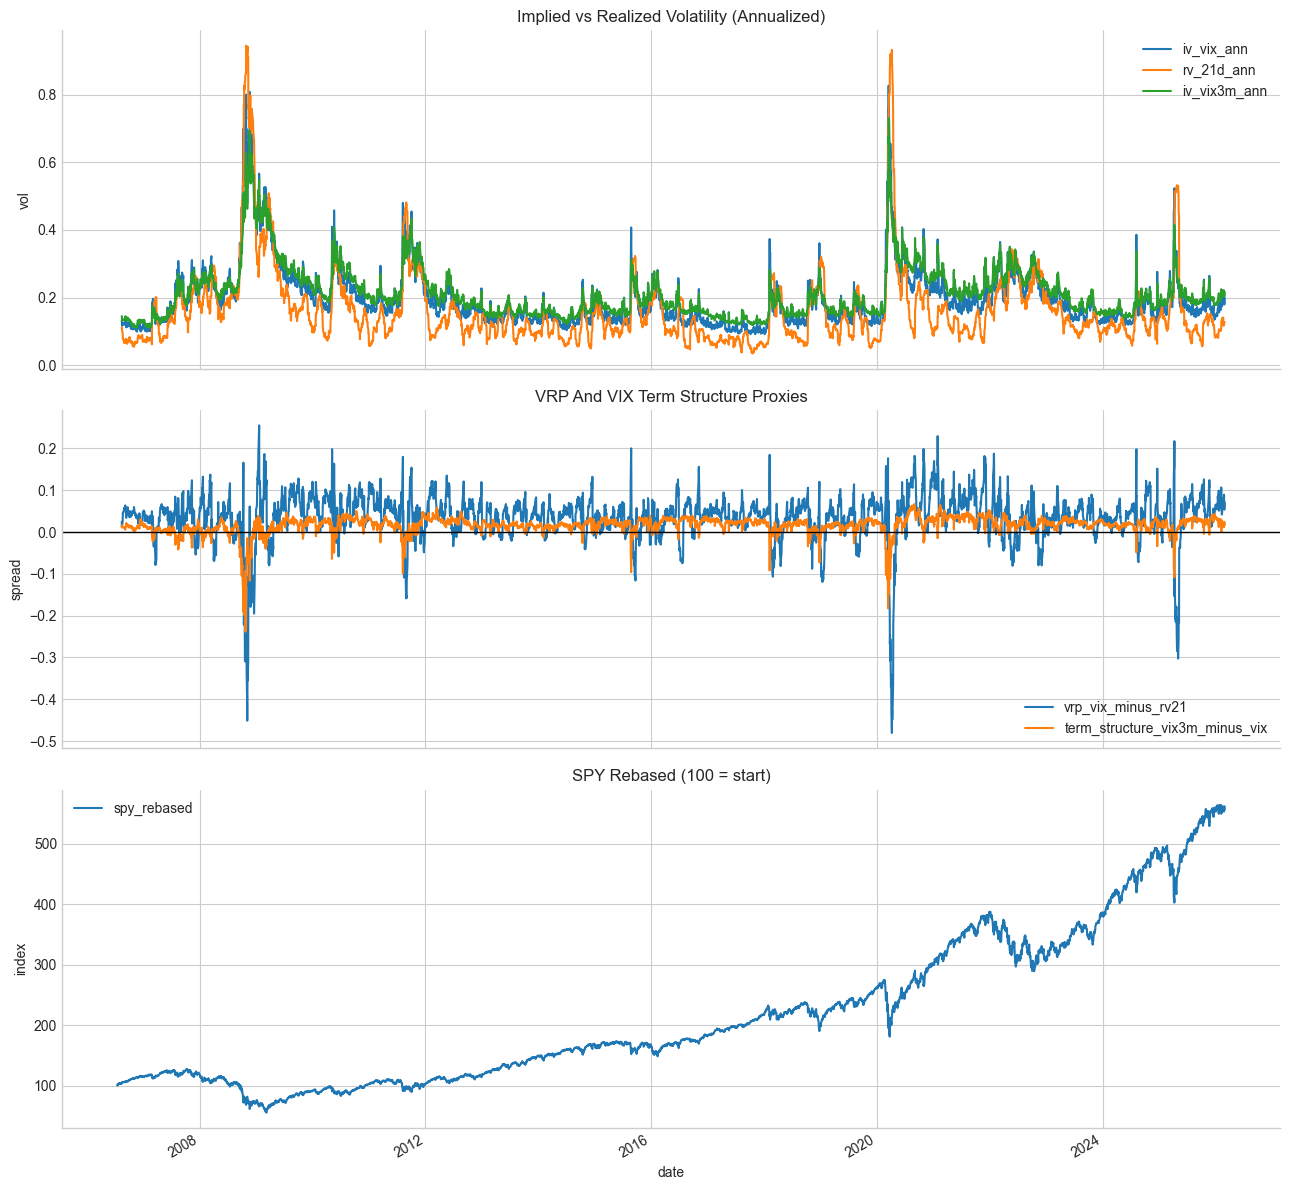

                   spy    vix      vix3m  rv_21d_ann  vrp_vix_minus_rv21  fwd_21d_spy
date                                                                                 
2026-01-22  688.979980  15.64  18.750000    0.105558            0.050842    -0.009565
2026-01-23  689.229980  16.09  19.150000    0.103556            0.057344    -0.002728
2026-01-26  692.729980  16.15  19.070000    0.103833            0.057667     0.000606
2026-01-27  695.489990  16.35  19.219999    0.104025            0.059475    -0.008900
2026-01-28  695.419983  16.35  19.299999    0.104025            0.059475    -0.013560

In [6]:
fig, axes = plt.subplots(3, 1, figsize=(13, 12), sharex=True)

panel[["iv_vix_ann", "rv_21d_ann", "iv_vix3m_ann"]].dropna().plot(
    ax=axes[0],
    title="Implied vs Realized Volatility (Annualized)",
)
axes[0].set_ylabel("vol")

panel[["vrp_vix_minus_rv21", "term_structure_vix3m_minus_vix"]].dropna().plot(
    ax=axes[1],
    title="VRP And VIX Term Structure Proxies",
)
axes[1].axhline(0.0, color="black", linewidth=1)
axes[1].set_ylabel("spread")

panel[["spy"]].dropna().assign(
    spy_rebased=lambda x: x["spy"] / x["spy"].iloc[0] * 100.0,
)[["spy_rebased"]].plot(
    ax=axes[2],
    color="tab:blue",
    title="SPY Rebased (100 = start)",
)
axes[2].set_ylabel("index")

plt.tight_layout()
plt.show()

panel.to_csv(OUT_CSV)
print("saved:", OUT_CSV)
panel[["spy", "vix", "vix3m", "rv_21d_ann", "vrp_vix_minus_rv21", "fwd_21d_spy"]].dropna().tail()
